# Polynomial Regression

## Intuition
What if your data looks like a **U-shape** or a **S-shape**? A straight line (y = mx + b) will never fit it. This is called **Underfitting**.

> Polynomial Regression is a form of linear regression where the relationship between the independent variable (x) and the dependent variable (y) is modelled as an $n^{th}$ degree polynomial. It is useful when the data exhibits a non-linear relationship allowing the model to fit a curve to the data.

To implement Polynomial Regression, we don't actually change the Linear Regression algorithm. Instead, we transform our data. 

If we have one feature x (Experience), we create a fake second feature by squaring x.
- **Linear:** y = mx + b
- **Polynomial:** y = $m_{0} + m_{1}x + m_{2}x^{2}$

Even though the line looks curbed on a graph, the math is still "linear" because the weights(m) are not squared. We just treated $x_{2}$ as if it were a new, independent feature.
### The Fake Feature / Dimentionality?
We need the model to include $x^{2}$ to create a curve. But our Linear Regression algorithm only knows how to multiply a feature by a weight and add them up. It doesn't know how to square something. <br/> <br/>
`Original Data Matrix:`
$$
X = \begin{bmatrix}
-2 \\
-1 \\
0 \\
1 \\
2
\end{bmatrix}
$$
`Transformed Data Matrix:` We decide to give the model 2 features: the original x and a new feature which is just x squared. Let's call them $x_{1}$ and $x{2}$.

**$x_{1} = x$**, **$x_{2} = x^{2}$**
$$
x_{new}= \begin{bmatrix}
1 \\
2 \\
3 \\
4 \\
5
\end{bmatrix}
$$
`The Linear Equation:` Now, we feed this $x_{new}$ into our **Multiple Linear Regression** algorithm. The algorithm sees two independent features. It thinks it is solving:
y = $m_{0} + m_{1}x_{1} + m_{2}x_{2}$

It calculates the weights and finds:
- $m_{0}$ = 0
- $m_{1}$ = 0
- $m_{2}$ = 1

> #### Result: y = (0) + (0)x + (1)$x_{2}$ &rarr; y = $x^{2}$

## Implementation of Polynomial Regression 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

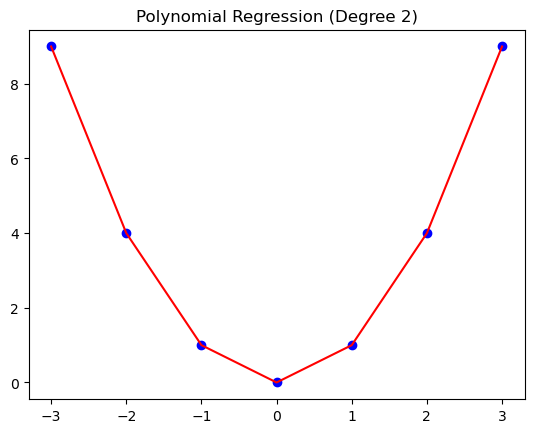

In [2]:
# Create Non-Linear Data (a parabola)
X = np.array([-3, -2, -1, 0, 1, 2, 3]).reshape(-1, 1)
y = np.array([9, 4, 1, 0, 1, 4, 9]) # y = x^2

# Transform the data to Polynomial
# We take X and add a column of X^2
X_poly = np.c_[X, X**2] 

# Use our existing Multiple Linear Regression logic
poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# 4. Predict
y_pred = poly_model.predict(X_poly)

# Visualize
plt.scatter(X, y, color='blue')
plt.plot(X, y_pred, color='red')
plt.title("Polynomial Regression (Degree 2)")
plt.show()